## `Mental Health Sentiment Analysis`

In [31]:
import pandas as pd 
import numpy as np
from functions import DataCheck
import matplotlib.pyplot as plt 
import nltk
import string
import pickle as pkl
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the data
data = pd.read_csv('mental_health_data/Combined Data.csv', index_col=0)
data.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
# Shape of data
data.shape

(53043, 2)

`Data Cleaning`

In [5]:
data_check = DataCheck(data)

# Missing data
data_check.miss_data()
print("---------------")

# Duplicated records
data_check.dup_data()

Missing data:  statement    362
status         0
dtype: int64
---------------
Duplicates:  1944


In [6]:
# Drop the missing records
data.dropna(inplace=True)

# Drop duplicated records
data.drop_duplicates(inplace=True)

`1. Lower Text`

In [7]:
# Create cleaning set of the text column
data['clean_text'] = data['statement'].apply(lambda x: x.lower())
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"trouble sleeping, confused mind, restless hear..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"all wrong, back off dear, forward doubt. stay ..."
3,I've shifted my focus to something else but I'...,Anxiety,i've shifted my focus to something else but i'...
4,"I'm restless and restless, it's been a month n...",Anxiety,"i'm restless and restless, it's been a month n..."


`2. Remove punctuations`

In [8]:
punc = string.punctuation
data['clean_text'] = data['clean_text'].apply(lambda x: x.translate(str.maketrans('', '', punc)))
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,Anxiety,ive shifted my focus to something else but im ...
4,"I'm restless and restless, it's been a month n...",Anxiety,im restless and restless its been a month now ...


`3. Tokenize`

In [9]:
data['clean_text'] = data['clean_text'].apply(lambda x: word_tokenize(x))
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,"[oh, my, gosh]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"[trouble, sleeping, confused, mind, restless, ..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"[all, wrong, back, off, dear, forward, doubt, ..."
3,I've shifted my focus to something else but I'...,Anxiety,"[ive, shifted, my, focus, to, something, else,..."
4,"I'm restless and restless, it's been a month n...",Anxiety,"[im, restless, and, restless, its, been, a, mo..."


`4. Handling stopwords`

In [10]:
stp_words = set(stopwords.words('english'))
data['clean_text'] = data['clean_text'].apply(lambda x: [word for word in x if word not in stp_words])
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,"[oh, gosh]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"[trouble, sleeping, confused, mind, restless, ..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"[wrong, back, dear, forward, doubt, stay, rest..."
3,I've shifted my focus to something else but I'...,Anxiety,"[ive, shifted, focus, something, else, im, sti..."
4,"I'm restless and restless, it's been a month n...",Anxiety,"[im, restless, restless, month, boy, mean]"


`5. Lemmatization`

In [11]:
data['clean_text'] = data['clean_text'].apply(lambda x: [WordNetLemmatizer().lemmatize(word) for word in x])
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,"[oh, gosh]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"[trouble, sleeping, confused, mind, restless, ..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"[wrong, back, dear, forward, doubt, stay, rest..."
3,I've shifted my focus to something else but I'...,Anxiety,"[ive, shifted, focus, something, else, im, sti..."
4,"I'm restless and restless, it's been a month n...",Anxiety,"[im, restless, restless, month, boy, mean]"


`6. Join Tokens`

In [12]:
data['clean_text'] = [" ".join(token) for token in data['clean_text']]
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,oh gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,Anxiety,ive shifted focus something else im still worried
4,"I'm restless and restless, it's been a month n...",Anxiety,im restless restless month boy mean


`7. Label Encoding`

In [13]:
encoder = LabelEncoder()
data['target_enc'] = encoder.fit_transform(data['status'])
data.head()

,statement,status,clean_text,target_enc
0,oh my gosh,Anxiety,oh gosh,0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...,0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...,0
3,I've shifted my focus to something else but I'...,Anxiety,ive shifted focus something else im still worried,0
4,"I'm restless and restless, it's been a month n...",Anxiety,im restless restless month boy mean,0


`Preprocessing  `

In [14]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['clean_text'])
y = data['target_enc']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42)

`Modelling`

Training Accuracy: 0.5581053970739346
Training Precision: 0.7694139835623983
-----------------------------
Testing Accuracy: 0.5064096291222233
Testing Precision: 0.6836921925165877


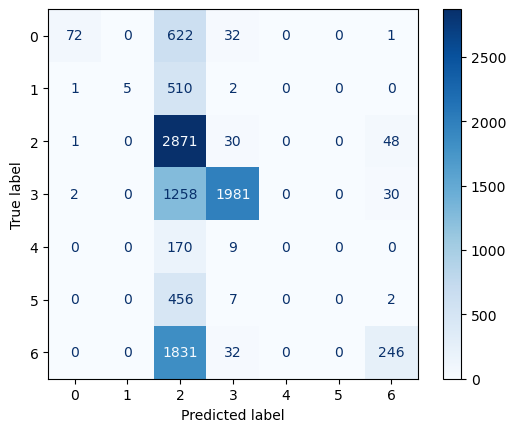

In [15]:
def classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    # Metrics
    train_preds = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, train_preds))
    print("Training Precision:", precision_score(y_train, train_preds, average='weighted'))
    print("-----------------------------")

    test_preds = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, test_preds))
    print("Testing Precision:", precision_score(y_test, test_preds, average='weighted'))
    cm = confusion_matrix(y_test, test_preds)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    display.plot(cmap=plt.cm.Blues)

classifier(MultinomialNB(), X_train, y_train, X_test, y_test)

Training Accuracy: 0.8262954445368694
Training Precision: 0.8275267238590782
-----------------------------
Testing Accuracy: 0.7446912613758685
Testing Precision: 0.7422377875740142


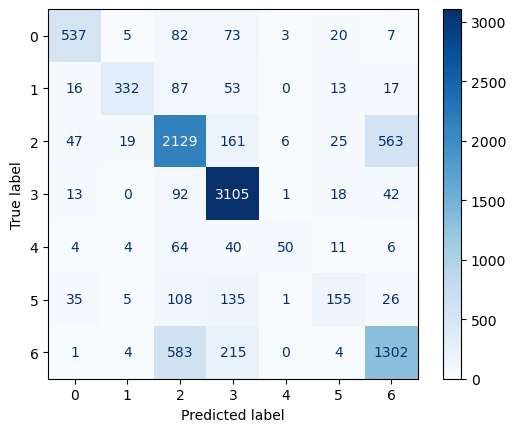

In [16]:
# Logistic Regression
classifier(LogisticRegression(max_iter=1000), X_train, y_train, X_test, y_test)

Training Accuracy: 0.3308460145813965
Training Precision: 0.6816435938478275
-----------------------------
Testing Accuracy: 0.33114786182601036
Testing Precision: 0.5685320208952377


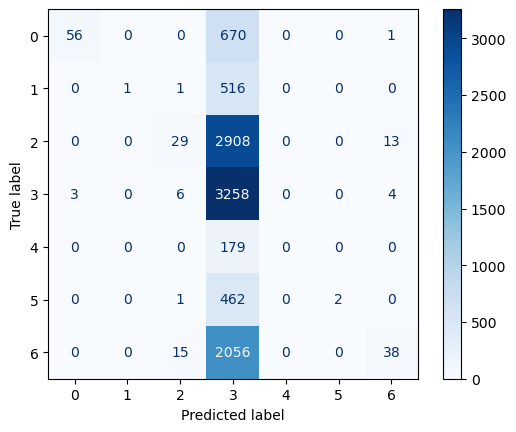

In [17]:
# K-Nearest Neighbors
classifier(KNeighborsClassifier(n_neighbors=5), X_train, y_train, X_test, y_test)

Training Accuracy: 0.9991192445075109
Training Precision: 0.9991202286702378
-----------------------------
Testing Accuracy: 0.6303943634406498
Testing Precision: 0.6233377381764422


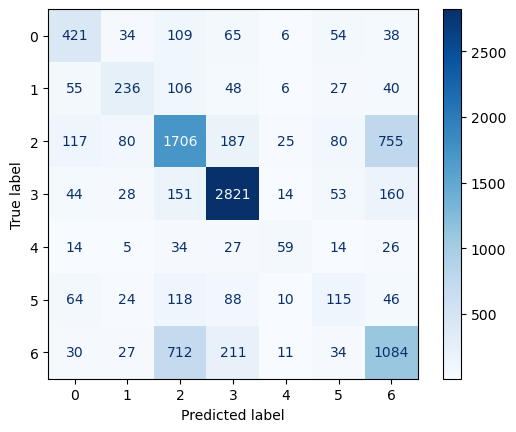

In [18]:
# Decision Tree
classifier(DecisionTreeClassifier(), X_train, y_train, X_test, y_test)

Training Accuracy: 0.9991192445075109
Training Precision: 0.9991194661332994
-----------------------------
Testing Accuracy: 0.6606321557882376
Testing Precision: 0.7161912066969395


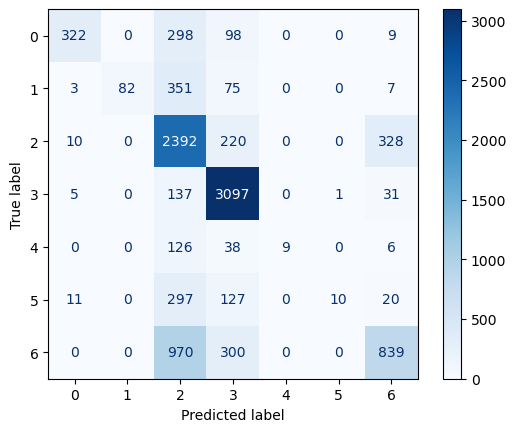

In [19]:
# Random Forest
classifier(RandomForestClassifier(n_estimators=100), X_train, y_train, X_test, y_test)

In [20]:
# Final model ~ Logistic regression
my_model = LogisticRegression(max_iter=1000)
my_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [21]:
# Save Model
with open('my_model.pkl', 'wb') as f:
    pkl.dump(my_model, f)

In [22]:
# Save the vectorizer
with open('vectorizer.pkl', 'wb') as f:
    pkl.dump(vectorizer, f)

`Predictions`

In [23]:
def predict_statement(statement):
    # Load the model and vectorizer
    with open('my_model.pkl', 'rb') as f:
        model = pkl.load(f)
    with open('vectorizer.pkl', 'rb') as f:
        vectorizer = pkl.load(f)

    # Preprocess the statement
    statement = statement.lower()
    statement = statement.translate(str.maketrans('', '', string.punctuation))
    statement = word_tokenize(statement)
    statement = [word for word in statement if word not in set(stopwords.words('english'))]
    statement = [WordNetLemmatizer().lemmatize(word) for word in statement]
    statement = " ".join(statement)

    # Transform the statement using the vectorizer
    statement_vectorized = vectorizer.transform([statement])

    # Make prediction
    prediction = model.predict(statement_vectorized)
    
    # Decode the prediction back to original label
    decoded_prediction = encoder.inverse_transform(prediction)
    
    return decoded_prediction[0]

In [24]:
# Test1
predict_statement("I feel anxious and stressed about my exams.")

'Stress'

In [25]:
# Test2
predict_statement("I have been feeling very down and hopeless lately.")

'Depression'

In [26]:
# Test4
predict_statement("I feel amazing")

'Normal'

### `Neural Network Model`

In [33]:
# The full TF-IDF matrix is (40874, 74127) float64 ≈ 22 GiB — too large to densify.
# Use a vocabulary-capped vectorizer (top 5000 terms) just for the neural network.
# The sklearn models already ran on the full vectorizer above, so they are unaffected.
nn_vectorizer = TfidfVectorizer(max_features=5000, dtype=np.float32)
X_nn = nn_vectorizer.fit_transform(data['clean_text'])
y_nn = data['target_enc']

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42
)

# Now safe to densify: (40874, 5000) float32 ≈ 800 MB
X_train_dense = X_train_nn.toarray()
X_test_dense  = X_test_nn.toarray()

num_classes = len(encoder.classes_)  # 7
y_train_cat = to_categorical(y_train_nn, num_classes=num_classes)
y_test_cat  = to_categorical(y_test_nn,  num_classes=num_classes)

print(f"X_train shape: {X_train_dense.shape}  dtype: {X_train_dense.dtype}")
print(f"y_train shape: {y_train_cat.shape}")

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax'),
])
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

results = model.fit(X_train_dense,
                    y_train_cat,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

X_train shape: (40874, 5000)  dtype: float32
y_train shape: (40874, 7)
Epoch 1/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6277 - loss: 0.9875 - val_accuracy: 0.7218 - val_loss: 0.7499
Epoch 2/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7500 - loss: 0.6783 - val_accuracy: 0.7339 - val_loss: 0.7218
Epoch 3/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7963 - loss: 0.5632 - val_accuracy: 0.7357 - val_loss: 0.7341
Epoch 4/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8264 - loss: 0.4846 - val_accuracy: 0.7385 - val_loss: 0.7560
Epoch 5/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8518 - loss: 0.4106 - val_accuracy: 0.7348 - val_loss: 0.7999
Epoch 6/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8744 - loss: 0.3514 - val_accuracy: 0.7314 - val_loss: 0.8741
Epoch 7/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8925 - loss: 0.3079 - val_accuracy: 0.7336 - val_loss: 0.9483
Epoch 8/10
1022

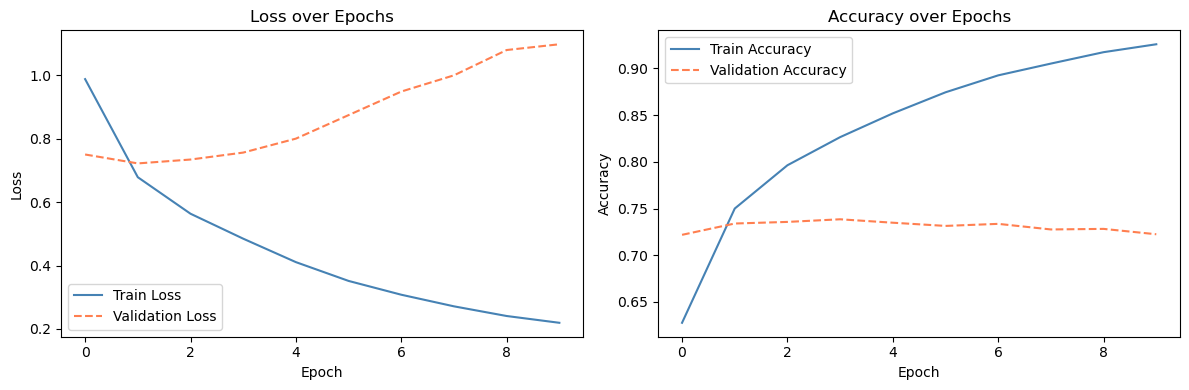


Test Loss:     1.0458
Test Accuracy: 0.7291

                       precision    recall  f1-score   support

             Anxiety       0.78      0.75      0.77       727
             Bipolar       0.83      0.69      0.76       518
          Depression       0.66      0.67      0.66      2950
              Normal       0.88      0.92      0.90      3271
Personality disorder       0.69      0.42      0.52       179
              Stress       0.47      0.44      0.45       465
            Suicidal       0.60      0.62      0.61      2109

            accuracy                           0.73     10219
           macro avg       0.70      0.64      0.67     10219
        weighted avg       0.73      0.73      0.73     10219



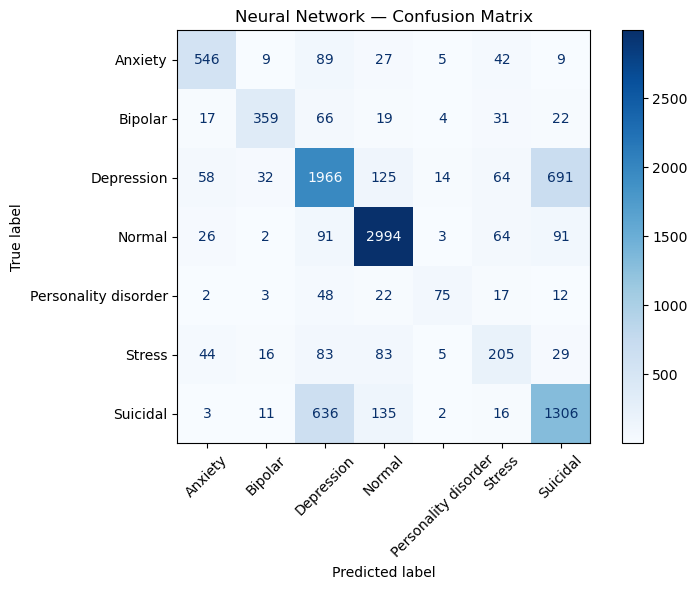

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(results.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(results.history['val_loss'], label='Validation Loss', color='coral', linestyle='--')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy curve
axes[1].plot(results.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(results.history['val_accuracy'], label='Validation Accuracy', color='coral', linestyle='--')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluation on test set
loss, acc = model.evaluate(X_test_dense, y_test_cat, verbose=0)
print(f"\nTest Loss:     {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")

# Classification report (convert one-hot back to integer labels for sklearn)
y_pred_probs = model.predict(X_test_dense, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
print("\n", classification_report(y_test, y_pred, target_names=encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Neural Network — Confusion Matrix")
plt.tight_layout()
plt.show()